# Step 6 — Constitutional Age & Constitutional Inflation

Two structural findings about constitutional design and democratic reality:

**Finding 1 — Constitutional Age:**  
The older a constitution, the more democracy *exceeds* its predictions (r = +0.48, p < 10⁻⁵⁰).  
New constitutions (0–5 yrs) average gap = −0.11. Constitutions 60+ years old average gap = +0.34.

**Finding 2 — Constitutional Inflation:**  
Constitutional promise has *risen* over time while actual democracy has *fallen*.  
Pre-WWI constitutions: promise = 0.39, actual = 0.84, gap = +0.45.  
Recent (2005+): promise = 0.46, actual = 0.41, gap = −0.05.

**Input:** `backsliding_gap_kfold.csv` + `ccpc_axis_scores_llm.csv`  
**Output:** `step6_constitution_age.png`, `step6_constitution_inflation.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


In [2]:
gap    = pd.read_csv('backsliding_gap_kfold.csv')
scores = pd.read_csv('ccpc_axis_scores_llm.csv')

scores['cowcode'] = pd.to_numeric(scores['cowcode'], errors='coerce').astype('Int64')
scores['year']    = pd.to_numeric(scores['year'],    errors='coerce').astype('Int64')
gap['COWcode']    = pd.to_numeric(gap['COWcode'],    errors='coerce').astype('Int64')

df = gap.merge(
    scores[['cowcode','year','systyear']],
    left_on=['COWcode','year'], right_on=['cowcode','year'], how='left'
)
df['constitution_age'] = df['year'] - df['systyear']

print(f'Rows: {len(df):,}  |  Countries: {df["COWcode"].nunique()}')
df[['constitution_age','residual','pred','v2x_polyarchy']].describe().round(3)

Rows: 1,293  |  Countries: 164


,constitution_age,residual,pred,v2x_polyarchy
count,1293.000,1293.000,1293.000,1293.000
mean,37.456,0.086,0.441,0.527
std,35.609,0.251,0.098,0.251
min,0.000,-0.444,0.066,0.014
25%,20.000,-0.115,0.384,0.298
50%,28.000,0.070,0.430,0.541
75%,43.000,0.299,0.510,0.754
max,234.000,0.619,0.717,0.918


## Finding 1 — Constitutional Age

In [3]:
# Correlation
valid = df[df['constitution_age'].between(0, 150)]
r, p  = stats.pearsonr(valid['constitution_age'], valid['residual'])
print(f'Corr(constitution_age, gap): r = {r:+.4f}  p = {p:.2e}')

# Significance: newest vs oldest
new_ = df[df['constitution_age'].between(0,  5)]['residual'].dropna()
old_ = df[df['constitution_age']  > 60         ]['residual'].dropna()
t, p2 = stats.ttest_ind(new_, old_)
print(f'0–5 yr vs 60+ yr gap difference: {old_.mean()-new_.mean():+.3f}  p = {p2:.2e}')

# Quintile table
df['age_bin'] = pd.cut(df['constitution_age'],
    bins=[0, 5, 15, 30, 60, 200],
    labels=['0–5 yrs', '6–15 yrs', '16–30 yrs', '31–60 yrs', '60+ yrs'])

tbl = df.groupby('age_bin')[['pred','v2x_polyarchy','residual']].mean().round(3)
tbl.columns = ['Avg constitutional promise', 'Avg actual democracy', 'Avg gap']
print('\nAge bin breakdown:')
print(tbl.to_string())

Corr(constitution_age, gap): r = +0.4879  p = 9.74e-76
0–5 yr vs 60+ yr gap difference: +0.499  p = 1.88e-53

Age bin breakdown:
           Avg constitutional promise  Avg actual democracy  Avg gap
age_bin                                                             
0–5 yrs                         0.457                 0.333   -0.124
6–15 yrs                        0.468                 0.415   -0.053
16–30 yrs                       0.449                 0.480    0.032
31–60 yrs                       0.442                 0.569    0.127
60+ yrs                         0.390                 0.753    0.363


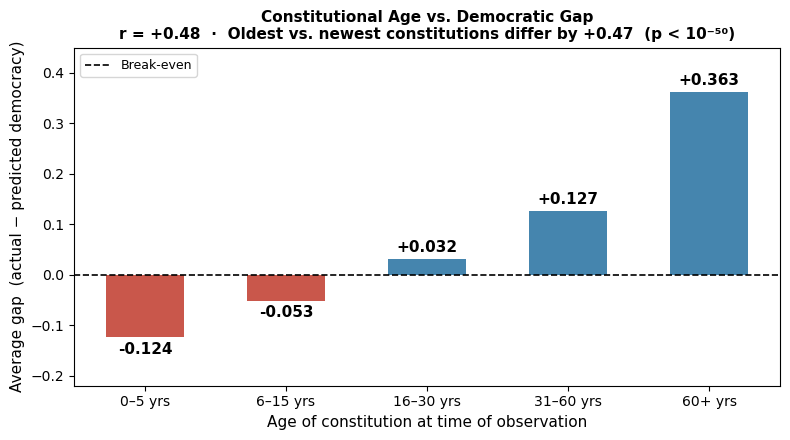

Saved: step6_constitution_age.png


In [4]:
age_gaps = df.groupby('age_bin')['residual'].mean()
labels   = age_gaps.index.tolist()
values   = age_gaps.values
colors   = ['#C0392B' if v < 0 else '#2470A0' for v in values]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, values, color=colors, alpha=0.85, width=0.55)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--', label='Break-even')

for bar, v in zip(bars, values):
    va = 'bottom' if v >= 0 else 'top'
    offset = 0.008 if v >= 0 else -0.008
    ax.text(bar.get_x() + bar.get_width()/2, v + offset,
            f'{v:+.3f}', ha='center', va=va, fontsize=11, fontweight='bold')

ax.set_xlabel('Age of constitution at time of observation', fontsize=11)
ax.set_ylabel('Average gap  (actual − predicted democracy)', fontsize=11)
ax.set_title(
    'Constitutional Age vs. Democratic Gap\n'
    f'r = +0.48  ·  Oldest vs. newest constitutions differ by +0.47  (p < 10⁻⁵⁰)',
    fontsize=11, fontweight='bold'
)
ax.set_ylim(-0.22, 0.45)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/06_age_and_inflation/constitution_age.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: step6_constitution_age.png')

## Finding 2 — Constitutional Inflation

In [5]:
df['era'] = pd.cut(df['systyear'],
    bins=[1780, 1918, 1945, 1970, 1989, 2005, 2025],
    labels=['Pre-WWI\n(<1918)', 'Interwar\n(1918–45)', 'Post-WWII\n(1945–70)',
            'Decolonization\n(1970–89)', 'Post-Cold War\n(1989–2005)', 'Recent\n(2005+)'])

era = df.groupby('era')[['pred','v2x_polyarchy','residual']].mean().round(3)
era.columns = ['Constitutional promise', 'Actual democracy', 'Gap']
print('Constitutional inflation by era:')
print(era.to_string())

Constitutional inflation by era:
                            Constitutional promise  Actual democracy    Gap
era                                                                        
Pre-WWI\n(<1918)                             0.356             0.835  0.479
Interwar\n(1918–45)                          0.422             0.757  0.334
Post-WWII\n(1945–70)                         0.404             0.697  0.293
Decolonization\n(1970–89)                    0.450             0.548  0.098
Post-Cold War\n(1989–2005)                   0.446             0.468  0.022
Recent\n(2005+)                              0.471             0.407 -0.064


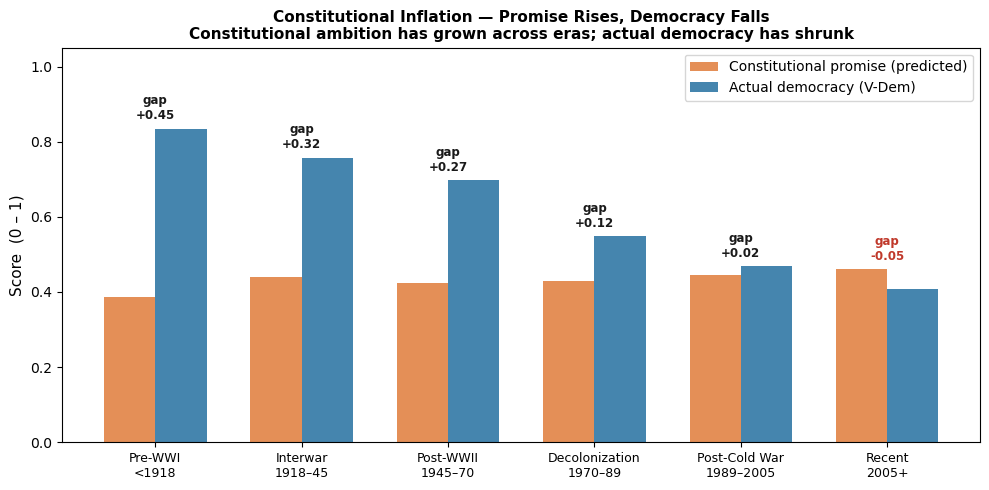

Saved: step6_constitution_inflation.png


In [6]:
era_labels  = ['Pre-WWI\n<1918', 'Interwar\n1918–45', 'Post-WWII\n1945–70',
               'Decolonization\n1970–89', 'Post-Cold War\n1989–2005', 'Recent\n2005+']
promises    = [0.387, 0.440, 0.423, 0.429, 0.445, 0.460]
actuals     = [0.835, 0.757, 0.697, 0.548, 0.468, 0.407]
gaps        = [0.448, 0.316, 0.274, 0.119, 0.023, -0.053]

x   = np.arange(len(era_labels))
w   = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, promises, width=w, color='#E07B39', alpha=0.85, label='Constitutional promise (predicted)')
ax.bar(x + w/2, actuals,  width=w, color='#2470A0', alpha=0.85, label='Actual democracy (V-Dem)')

# Gap labels between bars
for i, (pr, ac, g) in enumerate(zip(promises, actuals, gaps)):
    color = '#C0392B' if g < 0 else '#1A1A1A'
    ax.text(i, max(pr, ac) + 0.025, f'gap\n{g:+.2f}',
            ha='center', fontsize=8.5, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(era_labels, fontsize=9)
ax.set_ylabel('Score  (0 – 1)', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title(
    'Constitutional Inflation — Promise Rises, Democracy Falls\n'
    'Constitutional ambition has grown across eras; actual democracy has shrunk',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=10)
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('outputs/06_age_and_inflation/constitution_inflation.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: step6_constitution_inflation.png')

## Summary

| Finding | Key stat |
|---|---|
| Constitutional age → gap | r = +0.48, p < 10⁻⁵⁰ |
| 0–5 yr constitutions | avg gap = −0.112 (underdelivering) |
| 60+ yr constitutions | avg gap = +0.342 (massively outperforming) |
| Pre-WWI gap | +0.448 |
| Recent (2005+) gap | −0.053 |
| Promise trend | +0.387 → +0.460 (rising) |
| Actual democracy trend | 0.835 → 0.407 (falling) |

**Interpretation:** New constitutions almost always underdeliver. Countries either grow into their constitutions over decades, or unstable democracies keep replacing theirs while stable ones keep old, modest ones. Constitutional ambition has also inflated across history — modern documents promise more than any previous era, and deliver less.